# **Day-Ahead Pricing Model**
**WU Vienna | SBWL Data Science | DSLab 2026S | Marbl Energy**

*Authors: Pavle Cvijanovic, Aleksandar Gradev, Aleksandar Milosavljevic, Vincent Skakala*

### Summary
Electricity prices are not drawn from a single distribution. Wind surplus produces hours with negative prices, scarcity events produce extreme spikes, while the vast majority of days follow a moderate intraday pattern. A single forecasting model trained on this mixture will be pulled in conflicting directions by all three simultaneously. We therefore partition each day into one of four regimes before forecasting: Leaf A (days with at least $X\%$ negative-price hours), Leaf B (days with at least one hour above the 95th percentile of training prices) and two normal-day clusters (C0 and C1) discovered via K-Means on a PCA-reduced feature space. A L1-L2 regularized logistic regression predicts the probability of a negative-price day and a multinomial XGBoost SoftMax classifier distributes the remaining probability mass among the spike and normal regimes. 24 expert XGBoost regressors per regime then each predict one hour of the price curve independently. The final 24-hour forecast is a probability-weighted average across all four regime experts.

# Outline

- [Section 1 - Data Loading and Validation](#Section-1---Data-Loading-and-Validation)
  - [Load and Parse](#Load-and-Parse)
  - [Frequency and Gap Check](#Frequency-and-Gap-Check)
  - [Missingness Report](#Missingness-Report)
  - [Outlier Inspection](#Outlier-Inspection)
  - [Validated Data Summary](#Validated-Data-Summary)
- [Section 2 - Feature Engineering](#Section-2---Feature-Engineering)
  - [Feature Engineering Design](#Feature-Engineering-Design)
  - [`build_daily_features()` Function](#build_daily_features()-Function)
  - [24-Hour Price Pivot Matrix](#24-Hour-Price-Pivot-Matrix)
  - [Feature Visualisation](#Feature-Visualisation)
- [Section 3 - Spike and Negative days](#Section-3---Spike-and-Negative-days)
  - [Negative-Price Day Analysis](#Negative-Price-Day-Analysis)
  - [Spike-Price Day Analysis](#Spike-Price-Day-Analysis)
- [Section 4 - Training and Testing](#Section-4---Training-and-Testing)
    - [Save fold definitions and build `df_train`](#We-save-the-fold-definitions-for-the-respective-bidding-zone.-From-there-we-create-df_train-.)
    - [Fit PCA and separate regimes](#We-use-df_train-to-fit-the-PCA-and-separate-the-regimes.)
    - [Model training and walk-forward validation (`load_or_train`)](#We-perform-the-model-training-and-the-walk-forward-validation.-The-function-load_or_train()-checks-if-model-cache-already-exists-in-./results/cache.-If-it-exists,-it-directly-loads-the-trained-model.-Otherwise-the-function-trains-and-validates-from-scratch-by-calling-the-function-walk_forward().)
    - [Inspect negative days](#inspect-negative-days)
    - [Inspect dropped values](#inspect-dropped-values)
    - [Count NAs (ENTSO-E columns)](#count-NAs-throughout-the-entso-e-columns)
    - [Save PCA factor loadings](#save-the-PCA-factor-loadings)
  - [Naive Baselines](#Naive-Baselines)
- [Section 5 - Evaluation](#Section-5---Evaluation)
  - [Confusion matrices](#Confusion-matrices)
  - [Overall Metrics](#Overall-Metrics)
  - [Regime-Level Metrics](#Regime-Level-Metrics)
  - [Fold-Level Metrics](#Fold-Level-Metrics)
- [Section 6 - Model Diagnostics](#Section-6---Model-Diagnostics)
  - [Actual vs Predicted Daily Mean Price](#Actual-vs-Predicted-Daily-Mean-Price)
  - [Average 24-Hour Profile per Regime](#Average-24-Hour-Profile-per-Regime)
  - [Error Distribution and Rolling WAPE](#Error-Distribution-and-Rolling-WAPE)
  - [Classifier Regime Probabilities Over Time](#Classifier-Regime-Probabilities-Over-Time)
  - [Best and Worst Predicted Days](#Best-and-Worst-Predicted-Days)
  - [Random Day Diagnostics](#Random-Day-Diagnostics)

In [1]:
# import neccessary libraries and modules

import pandas as pd
import dataclasses
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src.config import ZoneConfig, ColumnSchema, ModelConfig
from src.zones import _SHARED_COMMODITY,_SHARED_WEATHER,_SHARED_ENTSO,ZONES
from src.data import load_and_validate, report_missingness, impute, summarize_validated_data
from src.plotting import plot_price_distribution, plot_feature_summary, plot_hourly_errors, plot_timeseries_actual_vs_predicted,plot_regime_profiles, plot_error_distribution,plot_regime_probabilities, plot_confusion_matrix, plot_single_day_diagnostics
from src.features import build_daily_features, build_price_pivot_lag1
from src.model import compute_spike_threshold, build_leaf_masks, fit_pca_and_fcm, assemble_regime_labels, train_classifier_l2, train_classifier_l1, train_expert_models, predict_fold, run_fold, load_or_train,walk_forward
from src.evaluation import wape,mae, regime_metrics, fold_metrics, worst_best_days_wape,worst_best_days_mae, reconstruct_actual_regimes, confusion_matrix_l1, confusion_matrix_l2
from src.diagnostics import to_long_predictions, save_diagnostic_inputs

In [2]:
import sys
print(sys.executable)

c:\WU\SBWL Data Science\Course 5 - Data Science Lab\DSLab26S-marbl.energy\marbl_env\Scripts\python.exe


# Section 1 - Data Loading and Validation
### Load and Parse

Before any transformation, the raw data must be validated against four properties: timezone consistency, unbroken hourly frequency, absence of duplicate timestamps and acceptable data quality per column.

### Frequency and Gap Check

Electricity price data should have exactly one observation per UTC hour. Missing hours and duplicate hours must be identified and quantified before imputation decisions are made.

In [3]:
# select bidding zone
country = "DE-LU"

In [4]:
# load and check the hourly data
df_hourly = load_and_validate(ZONES[country])

Shape:        (28381, 13)
Index min:    2023-01-01 00:00:00+00:00
Index max:    2026-03-28 20:00:00+00:00
Index dtype:  datetime64[us, UTC]
Monotonic:    True
Expected hours:   28,389
Actual hours:     28,381
Missing hours:    8
Duplicate hours:  0

5 gap block(s):
  2023-10-29 00:00:00+00:00 -> 2023-10-29 01:00:00+00:00  (2h)
  2023-12-30 23:00:00+00:00 -> 2023-12-30 23:00:00+00:00  (1h)
  2024-10-27 00:00:00+00:00 -> 2024-10-27 01:00:00+00:00  (2h)
  2024-12-30 23:00:00+00:00 -> 2024-12-30 23:00:00+00:00  (1h)
  2025-10-26 00:00:00+00:00 -> 2025-10-26 01:00:00+00:00  (2h)

After reindex: (28389, 13)


### Missingness Report

Each column's missingness rate determines the imputation strategy. Short gaps in smooth variables (temperature, wind) are suitable for linear interpolation. Price gaps require more care because electricity prices are not smooth, here forward-fill is inappropriate.

In [5]:
# inspect missing values
report_missingness(df_hourly)

Missingness table:
                                   null_count  null_pct
wind_solar_forecast_Wind Onshore           14     0.049
generation_forecast                        14     0.049
wind_solar_forecast_Solar                  14     0.049
load_forecast_Forecasted Load              13     0.046
wind_solar_forecast_Wind Offshore          11     0.039
solar_radiation_W                           8     0.028
precipitation_mm                            8     0.028
wind_speed_10m                              8     0.028
temperature_2m                              8     0.028
price_eur_mwh                               8     0.028
brent_usd_bbl                               8     0.028
ttf_gas_eur_mwh                             8     0.028
co2_eua_eur_tonne                           8     0.028


In [6]:
# fill missing values by interpolation or forward-fill
df_hourly = impute(df_hourly,ZONES[country])

Missingness table:
                                   null_count  null_pct
wind_solar_forecast_Wind Onshore           14     0.049
generation_forecast                        14     0.049
wind_solar_forecast_Solar                  14     0.049
load_forecast_Forecasted Load              13     0.046
wind_solar_forecast_Wind Offshore          11     0.039
solar_radiation_W                           8     0.028
precipitation_mm                            8     0.028
wind_speed_10m                              8     0.028
temperature_2m                              8     0.028
price_eur_mwh                               8     0.028
brent_usd_bbl                               8     0.028
ttf_gas_eur_mwh                             8     0.028
co2_eua_eur_tonne                           8     0.028

Price: interpolated 8 gaps (<= 3h).
Weather temperature_2m: interpolated 8, 0 remaining.
Weather wind_speed_10m: interpolated 8, 0 remaining.
Weather precipitation_mm: interpolated 8, 0 remaining.

### Outlier Inspection

Extreme electricity prices are not errors. Scarcity events and renewable surplus events produce genuinely extreme values that carry important regime signal. The goal here is to identify and inspect.

p0.1 threshold:  -96.93 EUR/MWh
p99.9 threshold: 411.95 EUR/MWh
High outliers (>411.9): 29
Low outliers  (<-96.9):  29

Negative price hours: 1,376  (4.85% of total)


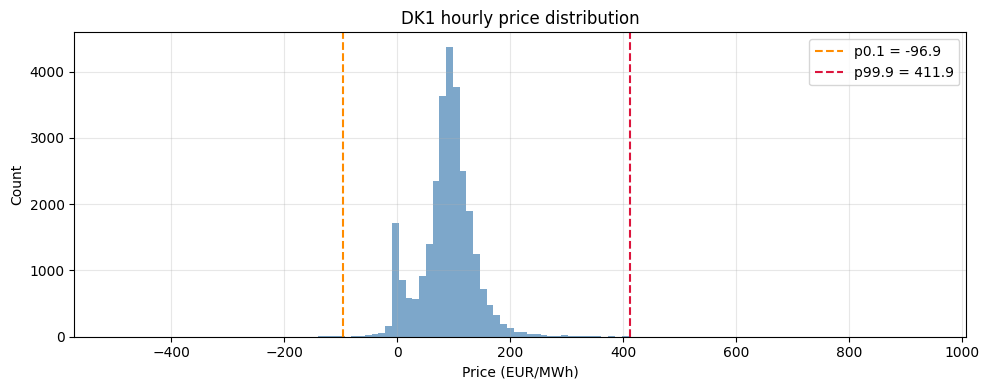

Saved: results/price_distribution.png


In [7]:
plot_price_distribution(df_hourly, ZONES[country])

### Validated Data Summary

The data is now clean and ready for feature engineering.

In [8]:
summarize_validated_data(df_hourly, ZONES[country])

=== Validated Data Summary ===
Total hours:           28,389
Total days:            1,183
Date range:            2023-01-01 -> 2026-03-28
Price mean:            88.78 EUR/MWh
Price std:             50.85 EUR/MWh
Price min:             -500.00 EUR/MWh
Price max:             936.28 EUR/MWh
Negative price hours:  4.85%

  temperature_2m               mean=10.007  std=7.259
  wind_speed_10m               mean=3.019  std=1.534
  precipitation_mm             mean=0.106  std=0.137
  solar_radiation_W            mean=127.463  std=190.421
  ttf_gas_eur_mwh              mean=37.664  std=8.933
  co2_eua_eur_tonne            mean=72.662  std=9.355
  brent_usd_bbl                mean=76.741  std=8.899
  load_forecast_Forecasted Load mean=53886.074  std=9107.545
  wind_solar_forecast_Solar    mean=7227.846  std=11160.197
  wind_solar_forecast_Wind Offshore mean=2938.976  std=1883.018
  wind_solar_forecast_Wind Onshore mean=13060.854  std=10004.027
  generation_forecast          mean=50411.264  std=1

# Section 2 - Feature Engineering


### Feature Engineering Design

Every feature for day T is constructed exclusively from information observable before noon on day T-1, the operational forecast window for the day-ahead auction. Day T-1 prices cleared at noon on day T-2 and are fully observable. Weather features for day T use ERA5 actuals as a proxy for the operational forecast; at inference time these will be replaced by WeatherAPI forecast values. Commodity features use the settlement price of day T-1.

Features fall into six groups: lag-1 price statistics, momentum, persistence signals, commodity signals, weather signals, and calendar encodings. Each group captures a distinct dimension of the information set available at forecast time.

The function accepts an optional spike_threshold parameter. When None, spike_streak_length is omitted from the output, handling the bootstrap case where the threshold has not yet been computed.

### `build_daily_features()` Function

This function does feature construction for the clustering part. It is called identically by the training pipeline, the walk-forward loop and the inference app. Any change here propagates everywhere.

The function is applied to the full hourly dataset here to produce the master daily dataframe. Walk-forward folds will slice this dataframe by date.

In [9]:

df_daily = build_daily_features(df_hourly, ZONES[country],spike_threshold=None)

print(f"Shape:          {df_daily.shape}")
print(f"Date range:     {df_daily.index.min().date()} -> {df_daily.index.max().date()}")
print(f"Missing values: {df_daily.isnull().sum().sum()}")
print(f"Columns ({len(df_daily.columns)}):")
for c in df_daily.columns:
    print(f"  {c}")
print()
print(df_daily.describe().round(3).to_string())
print("\nFirst 5 rows:")
print(df_daily.head().to_string())


Note: spike_threshold is None -- spike_streak_length omitted.
Shape:          (1183, 85)
Date range:     2023-01-01 -> 2026-03-28
Missing values: 51
Columns (85):
  price_mean_lag1
  price_std_lag1
  price_min_lag1
  price_max_lag1
  price_neg_frac_lag1
  was_negative_lag1
  price_range_lag1
  pivot_hour_peak_lag1
  pivot_hour_trough_lag1
  pivot_peak_sin
  pivot_peak_cos
  pivot_trough_sin
  pivot_trough_cos
  price_roll3_mean
  price_roll7_mean
  neg_streak_length
  ttf_lag1
  ttf_return_1d
  ttf_return_3d
  ttf_roll7_std
  co2_lag1
  co2_return_1d
  brent_return_3d
  spark_spread_proxy
  co2_gas_ratio
  wind_mean_t
  temp_mean_t
  solar_mean_t
  precip_sum_t
  temp_sq
  wind_power_proxy
  wind_chill
  supply_margin
  conventional_gen
  load_overnight
  load_morning
  load_midday
  load_evening
  load_night
  solar_overnight
  solar_morning
  solar_midday
  solar_evening
  solar_night
  wind_off_overnight
  wind_off_morning
  wind_off_midday
  wind_off_evening
  wind_off_night
  wind

### 24-Hour Price Pivot Matrix

The 24-hour price curve of each day encodes intraday shape information that scalar aggregates cannot capture. This pivot matrix is used as part of the combined feature vector fed into PCA before clustering. It represents day T-1 shape (the actual price curve that cleared yesterday).

In [10]:
price_pivot_lag1 = build_price_pivot_lag1(df_hourly, df_daily, ZONES[country])

price_pivot_lag1 shape: (1183, 24)
NaN count:              24

First 3 rows:
              h00    h01    h02    h03    h04     h05     h06     h07     h08     h09     h10     h11     h12     h13     h14     h15     h16     h17     h18     h19     h20     h21     h22     h23
date                                                                                                                                                                                                 
2023-01-01    NaN    NaN    NaN    NaN    NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN
2023-01-02  -1.07  -1.47  -5.08  -4.49  -5.40   -5.02   -1.30   -1.44   -1.09   -1.07   -1.07   -0.79   -0.27    0.85   23.53   36.54   46.03   55.57   54.95   49.23   44.99   45.96   35.00   57.91
2023-01-03  51.67  52.93  44.09  50.08  69.72  105.08  140.64  145.98  147.05  145.61  143.35  144.38  143.76  148.20  155.34  162.

### Feature Visualisation

Verify the features carry the expected economic signals before any modelling.

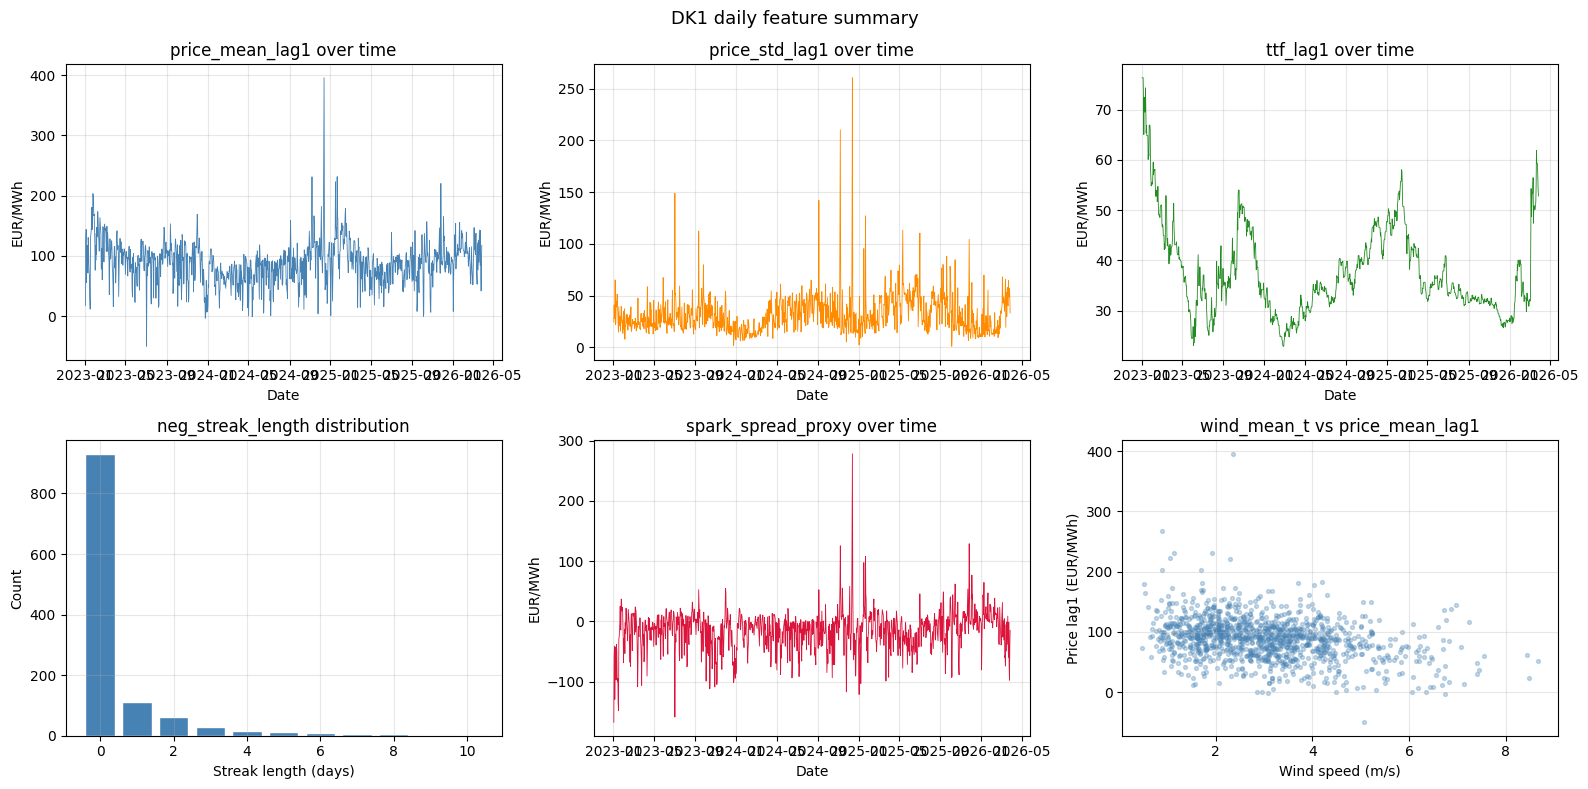

Saved: results/feature_summary.png


In [11]:
plot_feature_summary(df_daily, ZONES[country])

# Section 3 - Spike and Negative days

### Negative-Price Day Analysis

Unconditional and conditional probabilities of a negative-price day (≥1 hour with price < 0), plus a persistence/transition table for the negative-day state.

In [12]:
# build current-day negative flag from hourly data
_neg_raw = (
    df_hourly["price_eur_mwh"]
    .groupby(df_hourly.index.normalize().tz_localize(None))
    .min()
    .lt(0)
    .rename("neg_today")
)
neg_today = _neg_raw.reindex(df_daily.index)

# unconditional probability
p_neg = neg_today.mean()

# conditional probability on yesterday's status (was_negative_lag1 already in df_daily)
prev_neg = df_daily["was_negative_lag1"].astype(bool)
p_neg_given_neg_prev    = neg_today[prev_neg].mean()
p_neg_given_nonneg_prev = neg_today[~prev_neg].mean()
lift = p_neg_given_neg_prev / p_neg

print(f"{'P(negative day)':45s} = {p_neg:.3%}")
print(f"{'P(negative | yesterday negative)':45s} = {p_neg_given_neg_prev:.3%}")
print(f"{'P(negative | yesterday non-negative)':45s} = {p_neg_given_nonneg_prev:.3%}")
print(f"{'Lift  [P(neg|prev_neg) / P(neg)]':45s} = {lift:.2f}x")


P(negative day)                               = 21.471%
P(negative | yesterday negative)              = 56.471%
P(negative | yesterday non-negative)          = 11.853%
Lift  [P(neg|prev_neg) / P(neg)]              = 2.63x


In [13]:
# transition counts and probabilities

_lbl = {True: "Negative", False: "Non-negative"}

_trans = pd.DataFrame({
    "Today":    neg_today,
    "Tomorrow": neg_today.shift(-1),
}, index=neg_today.index).dropna().astype(bool)

_trans["Today_lbl"]    = _trans["Today"].map(_lbl)
_trans["Tomorrow_lbl"] = _trans["Tomorrow"].map(_lbl)

_counts = pd.crosstab(
    _trans["Today_lbl"],
    _trans["Tomorrow_lbl"],
    rownames=["Today \\ Tomorrow"],
    colnames=[""],
).rename_axis(index="Today \\ Tomorrow", columns="")

_probs = _counts.div(_counts.sum(axis=1), axis=0)

print("=== Transition Counts ===")
display(_counts)
print()
print("=== Row-Conditional Transition Probabilities ===")
display(_probs.round(4))


=== Transition Counts ===


,Negative,Non-negative
Today \ Tomorrow,,
Negative,143,111
Non-negative,110,818



=== Row-Conditional Transition Probabilities ===


,Negative,Non-negative
Today \ Tomorrow,,
Negative,0.5630,0.4370
Non-negative,0.1185,0.8815


In [14]:
# count of negative-price hours per day (all days in df_daily window)
_neg_hours = (
    df_hourly["price_eur_mwh"]
    .groupby(df_hourly.index.normalize().tz_localize(None))
    .apply(lambda x: (x < 0).sum())
    .rename("neg_hours")
    .reindex(df_daily.index)
)

# restrict to days that have at least 1 negative hour
_neg_days_hours = _neg_hours[_neg_hours > 0]

print(f"Days with ≥1 negative hour: {len(_neg_days_hours)} "
      f"({100*len(_neg_days_hours)/len(_neg_hours):.1f}% of all days)")
print()

_stats = _neg_days_hours.describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
_stats.index = ["count", "mean", "std", "min", "p10", "p25", "median", "p75", "p90", "max"]
print("Distribution of negative hours per negative day:")
print(_stats.round(2).to_string())
print()

# frequency table: how many days had exactly k negative hours
_freq = _neg_days_hours.value_counts().sort_index()
_freq_df = pd.DataFrame({
    "days":   _freq.values,
    "pct_of_neg_days": (100 * _freq / len(_neg_days_hours)).round(1),
}, index=_freq.index.astype(int))
_freq_df.index.name = "neg_hours"
print("Frequency table (how many negative days had exactly k negative hours):")
display(_freq_df)


Days with ≥1 negative hour: 254 (21.5% of all days)

Distribution of negative hours per negative day:
count     254.00
mean        5.42
std         3.42
min         1.00
p10         2.00
p25         3.00
median      5.00
p75         7.00
p90         9.00
max        24.00

Frequency table (how many negative days had exactly k negative hours):


,days,pct_of_neg_days
neg_hours,,
1,22,8.7
2,21,8.3
3,39,15.4
4,27,10.6
5,39,15.4
6,32,12.6
7,23,9.1
8,18,7.1
9,8,3.1


### Spike-Price Day Analysis

Unconditional and conditional probabilities of a spike-price day (≥1 hour exceeding a descriptive spike threshold - the 95th percentile of all hourly prices, mirroring `ModelConfig.spike_pct`), plus a persistence/transition table for the spike-day state.

Note: this threshold is a global descriptive cutoff for exploratory purposes. The model itself computes a fold-specific threshold from training-window prices only (see `compute_spike_threshold` later in the walk-forward section).

In [15]:
# descriptive spike threshold: 95th percentile of all available hourly prices
# (mirrors ModelConfig.spike_pct default = 95; fold-specific thresholds are computed
# later, inside compute_spike_threshold, from training windows only)
SPIKE_PCT = 95
price_col = ZONES[country].schema.price
spike_threshold_global = np.percentile(df_hourly[price_col].dropna(), SPIKE_PCT)
print(f"Descriptive spike threshold (p{SPIKE_PCT}): {spike_threshold_global:.2f} EUR/MWh")
print()

# build current-day spike flag from hourly data
_spike_raw = (
    df_hourly[price_col]
    .groupby(df_hourly.index.normalize().tz_localize(None))
    .max()
    .gt(spike_threshold_global)
    .rename("spike_today")
)
spike_today = _spike_raw.reindex(df_daily.index)

# unconditional
p_spike = spike_today.mean()

# conditional on yesterday's status:  df_daily has no was_spike_lag1 column
# (unlike was_negative_lag1), so derive the lag directly via shift(1)
prev_spike = spike_today.shift(1)
_valid = prev_spike.notna()
p_spike_given_spike_prev    = spike_today[_valid & prev_spike.astype(bool)].mean()
p_spike_given_nonspike_prev = spike_today[_valid & ~prev_spike.astype(bool)].mean()
lift = p_spike_given_spike_prev / p_spike

print(f"{'P(spike day)':45s} = {p_spike:.3%}")
print(f"{'P(spike | yesterday spike)':45s} = {p_spike_given_spike_prev:.3%}")
print(f"{'P(spike | yesterday non-spike)':45s} = {p_spike_given_nonspike_prev:.3%}")
print(f"{'Lift  [P(spike|prev_spike) / P(spike)]':45s} = {lift:.2f}x")


Descriptive spike threshold (p95): 160.59 EUR/MWh

P(spike day)                                  = 31.361%
P(spike | yesterday spike)                    = 54.717%
P(spike | yesterday non-spike)                = 20.715%
Lift  [P(spike|prev_spike) / P(spike)]        = 1.74x


In [16]:
_lbl = {True: "Spike", False: "Non-spike"}

_trans = pd.DataFrame({
    "Today":    spike_today,
    "Tomorrow": spike_today.shift(-1),
}, index=spike_today.index).dropna().astype(bool)

_trans["Today_lbl"]    = _trans["Today"].map(_lbl)
_trans["Tomorrow_lbl"] = _trans["Tomorrow"].map(_lbl)

_counts = pd.crosstab(
    _trans["Today_lbl"],
    _trans["Tomorrow_lbl"],
    rownames=["Today \\ Tomorrow"],
    colnames=[""],
).rename_axis(index="Today \\ Tomorrow", columns="")

_probs = _counts.div(_counts.sum(axis=1), axis=0)

print("=== Transition Counts ===")
display(_counts)
print()
print("=== Row-Conditional Transition Probabilities ===")
display(_probs.round(4))


=== Transition Counts ===


,Non-spike,Spike
Today \ Tomorrow,,
Non-spike,643,168
Spike,168,203



=== Row-Conditional Transition Probabilities ===


,Non-spike,Spike
Today \ Tomorrow,,
Non-spike,0.7928,0.2072
Spike,0.4528,0.5472


In [17]:
# Count of spike-price hours per day (all days in df_daily window)
_spike_hours = (
    df_hourly[price_col]
    .groupby(df_hourly.index.normalize().tz_localize(None))
    .apply(lambda x: (x > spike_threshold_global).sum())
    .rename("spike_hours")
    .reindex(df_daily.index)
)

# Restrict to days that have at least 1 spike hour
_spike_days_hours = _spike_hours[_spike_hours > 0]

print(f"Days with ≥1 spike hour: {len(_spike_days_hours)} "
      f"({100*len(_spike_days_hours)/len(_spike_hours):.1f}% of all days)")
print()

_stats = _spike_days_hours.describe(percentiles=[0.10, 0.25, 0.50, 0.75, 0.90])
_stats.index = ["count", "mean", "std", "min", "p10", "p25", "median", "p75", "p90", "max"]
print("Distribution of spike hours per spike day:")
print(_stats.round(2).to_string())
print()

# Frequency table: how many days had exactly k spike hours
_freq = _spike_days_hours.value_counts().sort_index()
_freq_df = pd.DataFrame({
    "days":   _freq.values,
    "pct_of_spike_days": (100 * _freq / len(_spike_days_hours)).round(1),
}, index=_freq.index.astype(int))
_freq_df.index.name = "spike_hours"
print("Frequency table (how many spike days had exactly k spike hours):")
display(_freq_df)


Days with ≥1 spike hour: 371 (31.4% of all days)

Distribution of spike hours per spike day:
count     371.00
mean        3.82
std         3.64
min         1.00
p10         1.00
p25         2.00
median      2.00
p75         5.00
p90         8.00
max        19.00

Frequency table (how many spike days had exactly k spike hours):


,days,pct_of_spike_days
spike_hours,,
1,91,24.5
2,99,26.7
3,55,14.8
4,32,8.6
5,17,4.6
6,17,4.6
7,16,4.3
8,9,2.4
9,5,1.3


# Section 4 - Training and Testing
We save the fold definitions for the respective bidding zone. From there we create `df_train()`

In [18]:
from src.zones import ZONES
from src.config import ModelConfig
from src import data, features, model, evaluation, plotting


model_cfg = ModelConfig()

fold_def = ZONES[country].fold_definitions[0]
tr_s, tr_e, _, _ = fold_def



spike_thr = model.compute_spike_threshold(df_hourly, tr_s, tr_e, ZONES[country], model_cfg)
print(f"Spike threshold: {spike_thr:.2f}")  # compare to original notebook print

df_train = df_daily[(df_daily.index >= tr_s) & (df_daily.index <= tr_e)]
mask_A, mask_B, mask_normal,use_ridge_regime = model.build_leaf_masks(
    df_train, df_hourly, spike_thr, ZONES[country], model_cfg
)
print(f"Leaf A: {mask_A.sum()}, Leaf B: {mask_B.sum()}, Normal: {mask_normal.sum()}")

  Spike threshold (fold): 166.25 EUR/MWh
Spike threshold: 166.25
  Leaf A: 42 days (11.5%) -- WARNING: small bucket, Ridge fallback for expert models
  Leaf B: 108 days (29.6%)
  Normal: 215 days (58.9%)
Leaf A: 42, Leaf B: 108, Normal: 215


We use `df_train` to fit the PCA and separate the regimes

In [19]:
pivot_train = price_pivot_lag1.reindex(df_train.index)
scaler, pca, cntr, hard_labels, normal_idx = model.fit_pca_and_fcm(
    df_train, pivot_train, mask_normal, model_cfg
)
regime_labels = model.assemble_regime_labels(
    df_train, mask_A, mask_B, mask_normal, hard_labels, normal_idx
)
print(regime_labels.value_counts().sort_index())  # 0=A, 1=B, 2=C0, 3=C1 counts

  PCA: 14 components retain 0.879 cumulative variance
  FKM C0: 107 days
  FKM C1: 107 days
0     42
1    108
2    108
3    107
Name: count, dtype: int64


We perform the model training and the walk-forward validation. The function `load_or_train()` checks if model cache already exists in ./results/cache. If it exists, it directly loads the trained model. Otherwise the function trains and validates from scratch by calling the function `walk_forward()`

In [20]:
df_preds, all_fold_models = load_or_train(
    ZONES[country], model_cfg, df_daily, price_pivot_lag1, df_hourly
)

[DE-LU] Loading cached results from results\cache\DE-LU
  Loaded 817 predictions, 3 folds


#### Inspect negative days

In [21]:
pc  = ZONES[country].schema.price
idx = df_hourly.index
day = (idx.tz_convert("UTC").tz_localize(None) if idx.tz is not None else idx).normalize()

neg_frac = pd.Series((df_hourly[pc].values < 0).astype(float), index=day).groupby(level=0).mean()
thr      = model_cfg.leaf_a_neg_frac_threshold
leaf_a   = neg_frac[neg_frac >= thr].index            # Leaf-A (negative) days

print(f"{country}: {len(leaf_a)} Leaf-A days total; "
      f"{(df_hourly[pc] < 0).sum()} negative hours overall")

for i, fold in enumerate(ZONES[country].fold_definitions, 1):
    s, e = pd.Timestamp(fold[0]), pd.Timestamp(fold[1])
    n = ((leaf_a >= s) & (leaf_a <= e)).sum()
    print(f"Fold {i}  train {s.date()}–{e.date()}: {n} Leaf-A days")

DE-LU: 211 Leaf-A days total; 1376 negative hours overall
Fold 1  train 2023-01-01–2023-12-31: 42 Leaf-A days
Fold 2  train 2023-01-01–2024-12-31: 111 Leaf-A days
Fold 3  train 2023-01-01–2025-12-31: 202 Leaf-A days


#### Inspect dropped values

In [22]:
import pandas as pd

fold = ZONES[country].fold_definitions[0]                 # the failing fold
tr_s, tr_e = pd.Timestamp(fold[0]), pd.Timestamp(fold[1])

df_train    = df_daily[(df_daily.index >= tr_s) & (df_daily.index <= tr_e)]
pivot_train = price_pivot_lag1.reindex(df_train.index)

combined     = pd.concat([df_train, pivot_train], axis=1)
df_train_clf = combined.dropna()
print("rows before dropna:", len(df_train), " after:", len(df_train_clf))

dropped = df_train.index.difference(df_train_clf.index)
if len(dropped):
    print("dropped range:", dropped.min().date(), "→", dropped.max().date(), f"({len(dropped)} rows)")

print("\nNaN columns forcing the drops:")
print(combined.isna().sum().loc[lambda s: s > 0].sort_values(ascending=False))

# how many Leaf-A days survive the dropna?
pc  = ZONES[country].schema.price
idx = df_hourly.index
day = (idx.tz_convert("UTC").tz_localize(None) if idx.tz is not None else idx).normalize()
neg_frac = pd.Series((df_hourly[pc].values < 0).astype(float), index=day).groupby(level=0).mean()
leaf_a   = neg_frac[neg_frac > model_cfg.leaf_a_neg_frac_threshold].index

def to_dates(ix):
    ix = pd.DatetimeIndex(ix)
    return set((ix.tz_localize(None) if ix.tz is not None else ix).normalize().date)

win  = to_dates(leaf_a[(leaf_a >= tr_s) & (leaf_a <= tr_e)])
surv = win & to_dates(df_train_clf.index)
print(f"\nLeaf-A days in window: {len(win)}   surviving dropna: {len(surv)}")

rows before dropna: 365  after: 361
dropped range: 2023-01-01 → 2023-01-04 (4 rows)

NaN columns forcing the drops:
ttf_return_3d                   4
brent_return_3d                 4
ttf_momentum3d_x_rl_evening     4
ttf_return_1d                   2
co2_return_1d                   2
ttf_momentum_x_rl_evening       2
commodity_momentum_composite    2
co2_momentum_x_rl_evening       2
ttf_roll7_std                   2
price_min_lag1                  1
price_max_lag1                  1
pivot_hour_peak_lag1            1
pivot_trough_sin                1
pivot_peak_cos                  1
price_std_lag1                  1
price_neg_frac_lag1             1
pivot_hour_trough_lag1          1
was_negative_lag1               1
price_range_lag1                1
price_mean_lag1                 1
co2_lag1                        1
price_roll3_mean                1
price_roll7_mean                1
ttf_lag1                        1
pivot_trough_cos                1
pivot_peak_sin                  1


#### Count NAs throughout the ENTSO-E columns

In [23]:
entso_cols = [c for c in df_hourly.columns if any(k in c for k in 
              ["wind_solar_forecast", "load_forecast", "generation_forecast"])]
print(df_hourly[entso_cols].loc["2024-01-01":"2024-12-31"].isna().mean().sort_values(ascending=False))

load_forecast_Forecasted Load        0.0
wind_solar_forecast_Solar            0.0
wind_solar_forecast_Wind Offshore    0.0
wind_solar_forecast_Wind Onshore     0.0
generation_forecast                  0.0
dtype: float64


#### Save the PCA factor loadings

In [24]:
df_loadings = model.extract_pca_loadings(df_daily, price_pivot_lag1, all_fold_models[0])
df_loadings.to_csv(
    model_cfg.results_dir/f"pca_loadings_fold_1_{country}.csv"
)

### Naive Baselines

Two baselines are added to df_preds. Naive 1 repeats yesterday's observed 24-hour price curve. Naive 2 averages the same 24-hour slots across the preceding seven days.

In [25]:
# Build full price-by-hour lookup from df_hourly.
_h = df_hourly.copy()
_h["_d"] = pd.to_datetime(_h.index.normalize().date)
_h["_hr"] = _h.index.hour
price_mat_eval = _h.pivot_table(index="_d", columns="_hr", values=ZONES[country].schema.price, aggfunc="mean")
price_mat_eval.index   = pd.to_datetime(price_mat_eval.index)
price_mat_eval.columns = list(range(24))

naive1_arr = np.full((len(df_preds), 24), np.nan)
naive2_arr = np.full((len(df_preds), 24), np.nan)

for i, date in enumerate(pd.to_datetime(df_preds["date"])):
    prev1 = date - pd.Timedelta(days=1)
    if prev1 in price_mat_eval.index:
        naive1_arr[i] = price_mat_eval.loc[prev1].values

    window = pd.date_range(end=date - pd.Timedelta(days=1), periods=7, freq="D")
    valid_w = [d for d in window if d in price_mat_eval.index]
    if valid_w:
        naive2_arr[i] = price_mat_eval.loc[valid_w].mean(axis=0).values

for h in range(24):
    df_preds[f"naive1_h{h:02d}"] = naive1_arr[:, h]
    df_preds[f"naive2_h{h:02d}"] = naive2_arr[:, h]

n1_valid = (~np.isnan(naive1_arr).any(axis=1)).sum()
n2_valid = (~np.isnan(naive2_arr).any(axis=1)).sum()
print(f"Valid naive 1 forecasts: {n1_valid} / {len(df_preds)}")
print(f"Valid naive 2 forecasts: {n2_valid} / {len(df_preds)}")


Valid naive 1 forecasts: 817 / 817
Valid naive 2 forecasts: 817 / 817


# Section 5 - Evaluation

### Confusion matrices


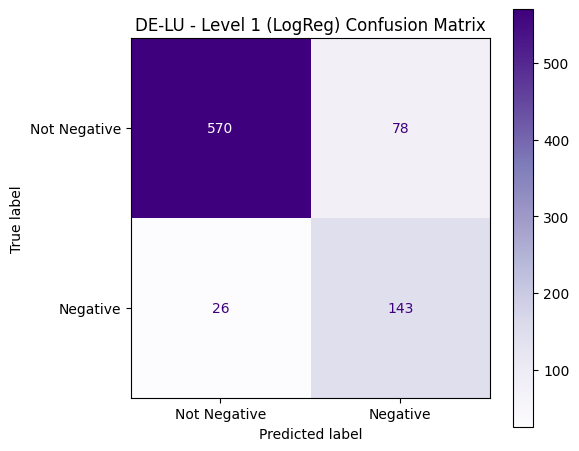


  [LEVEL 1 - TEST SET METRICS]
  ROC-AUC:     0.945
  PR-AUC:      0.820
  Brier Score: 0.094
              precision    recall  f1-score   support

Not Negative       0.96      0.88      0.92       648
    Negative       0.65      0.85      0.73       169

    accuracy                           0.87       817
   macro avg       0.80      0.86      0.82       817
weighted avg       0.89      0.87      0.88       817



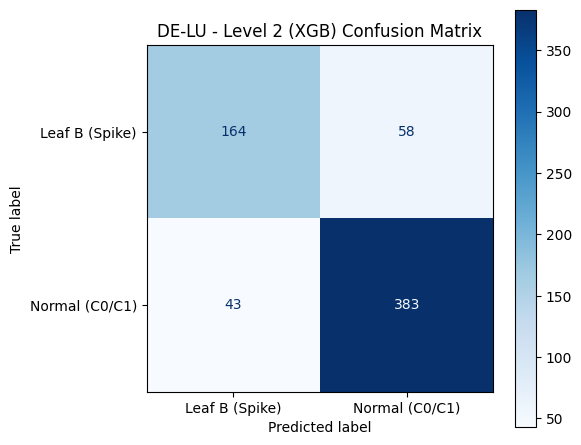


  [LEVEL 2 - TEST SET METRICS (Non-Negative Days)]
                precision    recall  f1-score   support

Leaf B (Spike)       0.79      0.74      0.76       222
Normal (C0/C1)       0.87      0.90      0.88       426

      accuracy                           0.84       648
     macro avg       0.83      0.82      0.82       648
  weighted avg       0.84      0.84      0.84       648



In [26]:
zone_cfg = ZONES[country]
# attach ground-truth labels
df_eval = reconstruct_actual_regimes(
    df_preds, df_hourly, all_fold_models, model_cfg, zone_cfg
)

# L1 confusion matrix + metrics
cm_l1 = confusion_matrix_l1(df_eval)
fig_l1 = plot_confusion_matrix(
    cm_l1["cm"],
    display_labels=cm_l1["display_labels"],
    title=f"{zone_cfg.zone} - Level 1 (LogReg) Confusion Matrix",
    cmap="Purples",
)
fig_l1.savefig(model_cfg.results_dir / f"cm_l1_{zone_cfg.zone}.png", dpi=120)
plt.show()

print(f"\n{'='*60}")
print(f"  [LEVEL 1 - TEST SET METRICS]")
print(f"{'='*60}")
print(f"  ROC-AUC:     {cm_l1['roc_auc']:.3f}")
print(f"  PR-AUC:      {cm_l1['pr_auc']:.3f}")
print(f"  Brier Score: {cm_l1['brier']:.3f}")
print(cm_l1["classification_report"])

# L2 confusion matrix + report
cm_l2 = confusion_matrix_l2(df_eval)
fig_l2 = plot_confusion_matrix(
    cm_l2["cm"],
    display_labels=cm_l2["display_labels"],
    title=f"{zone_cfg.zone} - Level 2 (XGB) Confusion Matrix",
    cmap="Blues",
)
fig_l2.savefig(model_cfg.results_dir / f"cm_l2_{zone_cfg.zone}.png", dpi=120)
plt.show()

print(f"\n{'='*60}")
print(f"  [LEVEL 2 - TEST SET METRICS (Non-Negative Days)]")
print(f"{'='*60}")
print(cm_l2["classification_report"])

### Overall Metrics

WAPE and MAE are computed over all test hours by flattening the full prediction matrix. NaN values (arising from test days with missing actual prices) are excluded.

In [27]:
act_flat  = df_preds[evaluation.HOUR_COLS].values.ravel()
pred_flat = df_preds[evaluation.PRED_COLS].values.ravel()
n1_flat   = df_preds[evaluation.NAIVE1_COLS].values.ravel()
n2_flat   = df_preds[evaluation.NAIVE2_COLS].values.ravel()

print("=== Overall Metrics ===")
print(f"{'Metric':<12} {'Model':>10} {'Naive 1':>10} {'Naive 2':>10}")
print("-" * 45)
print(f"{'WAPE (%)':<12} {wape(act_flat, pred_flat):>10.2f} {wape(act_flat, n1_flat):>10.2f} {wape(act_flat, n2_flat):>10.2f}")
print(f"{'MAE':<12} {mae(act_flat, pred_flat):>10.2f} {mae(act_flat, n1_flat):>10.2f} {mae(act_flat, n2_flat):>10.2f}")


=== Overall Metrics ===
Metric            Model    Naive 1    Naive 2
---------------------------------------------
WAPE (%)          17.38      30.83      31.10
MAE               15.14      26.86      27.09


 We calculate the percentage of test days where we assigned the correct cluster, based on our clustering rules

In [28]:
len(df_preds["effective_regime"].values)
df_eval[['p_A', 'p_B', 'p_C0', 'p_C1', 'effective_regime', 'actual_regime', 'actual_negative']]

df_eval["effective_regime_fix"] = np.where(
    df_eval["effective_regime"] == 3,
    2,
    df_eval["effective_regime"]
)

df_eval["regimes_match"] = df_eval["effective_regime_fix"] == df_eval["actual_regime"]

df_eval[['p_A', 'p_B', 'p_C0', 'p_C1', 'effective_regime', 'actual_regime', 'actual_negative', "effective_regime_fix", "regimes_match"]]

# How often we are correct when assigning cluster
probs_correct_regime = df_eval["regimes_match"].sum() / len(df_eval["regimes_match"])

print(f"Ratio of observations with highest probability assigned to the correct regime: {(probs_correct_regime*100).round(2)} %")

Ratio of observations with highest probability assigned to the correct regime: 74.79 %


We calculate the percentage of test days where the assigned cluster is correct with more than 50% and 90% probability.

In [29]:
df_eval["max_prob"] = df_eval[['p_A', 'p_B', 'p_C0', 'p_C1']].max(axis=1)

df_eval[['p_A', 'p_B', 'p_C0', 'p_C1', 'effective_regime', 'actual_regime', 'actual_negative', "effective_regime_fix", "regimes_match", "max_prob"]]

df_eval["regimes_match_90"] = (df_eval["effective_regime_fix"] == df_eval["actual_regime"]) & (df_eval["max_prob"] >= .90)
df_eval["regimes_match_50"] = (df_eval["effective_regime_fix"] == df_eval["actual_regime"]) & (df_eval["max_prob"] >= .50)

probs_90 = df_eval["regimes_match_90"].sum() / len(df_eval["regimes_match"])

probs_50 = df_eval["regimes_match_50"].sum() / len(df_eval["regimes_match"])

probs_all = df_eval["regimes_match"].sum() / len(df_eval["regimes_match"])

# When we are correct, we are correct with this much confidence (i.e. probability assigned to the cluster and finally being correct)
print(f"Ratio of correct predictions with 90% confidence: {((probs_90 / probs_all)*100).round(2)} %")
print(f"Ratio of correct predictions with 50% confidence: {((probs_50 / probs_all)*100).round(2)} %")

Ratio of correct predictions with 90% confidence: 14.73 %
Ratio of correct predictions with 50% confidence: 91.16 %


### Regime-Level Metrics

Each test day is assigned a dominant regime label as the argmax of its four probability columns. WAPE is suppressed for Regime A (negative-price days) because near-zero or negative denominators make WAPE undefined or misleading.

In [30]:
regime_metrics(df_preds)

  Note: WAPE suppressed for Regime A -- near-zero/negative price denominators.


,regime_name,n,share_pct,wape,mae,naive1_wape,naive2_wape
regime_label,,,,,,,
0,Leaf A (negative),248,30.354957,NaN,15.486687,NaN,NaN
1,Leaf B (spike),201,24.602203,16.445564,19.614956,25.583515,26.047488
2,C0 (normal),211,25.826193,13.557007,12.287109,25.242046,25.012427
3,C1 (normal),157,19.216646,14.534714,12.701764,24.179925,24.167905


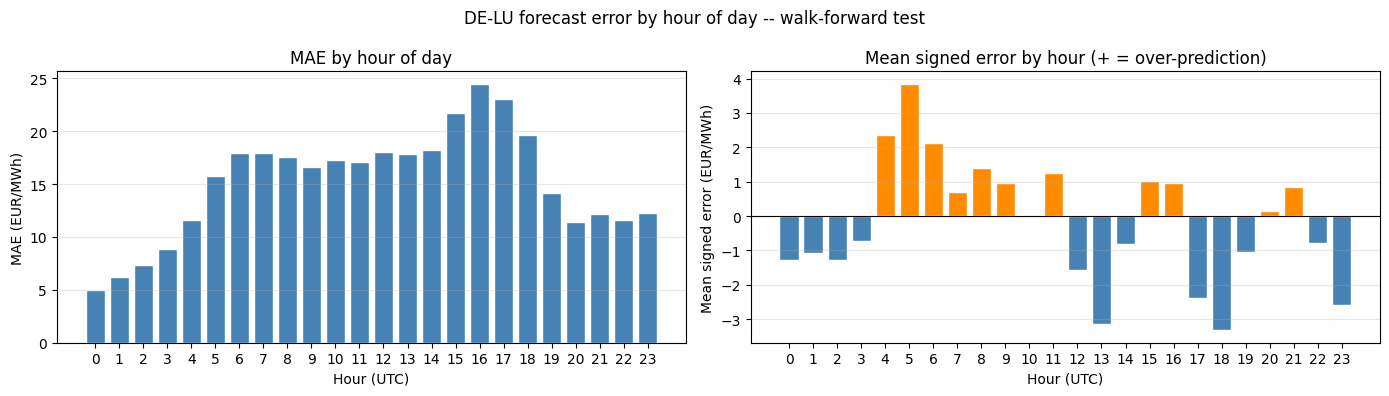

Saved: results/hourly_errors_DE-LU.png
Hours with highest MAE: ['h16 (24.43)', 'h17 (23.00)', 'h15 (21.68)']


In [31]:
plot_hourly_errors(df_preds, ZONES[country])

### Fold-Level Metrics

Tagging each prediction by fold number allows detection of distribution shift across time: if a later fold shows substantially worse WAPE relative to the naive baseline, it suggests the training regime mix no longer matches the test period.

In [32]:
fold_metrics(df_preds, ModelConfig, ZONES[country])

=== Fold-Level Metrics ===
Fold       N Test period                WAPE% model   WAPE% N1   WAPE% N2
---------------------------------------------------------------------------
1        366 2024-01-01 -> 2024-12-31         21.52      34.90      35.31
2        365 2025-01-01 -> 2025-12-31         15.08      28.61      29.48
3         86 2026-01-01 -> 2026-03-28         12.36      25.78      23.30

Saved: results/walk_forward_predictions_final_DE-LU.csv  (1016.2 KB)
Columns: 103  |  Rows: 817


# Section 6 - Model Diagnostics

Four diagnostic views examine where and why the model succeeds or fails: a time series overlay coloured by regime, the average 24-hour price curve per regime, the full distribution of prediction errors, and the trajectory of regime probabilities over the test period.

### Actual vs Predicted Daily Mean Price

The daily mean price collapses the 24-hour forecast to one number per day and makes systematic over- or under-prediction visible. The regime strip below the main panel shows the dominant regime assigned by the classifier on each test day.

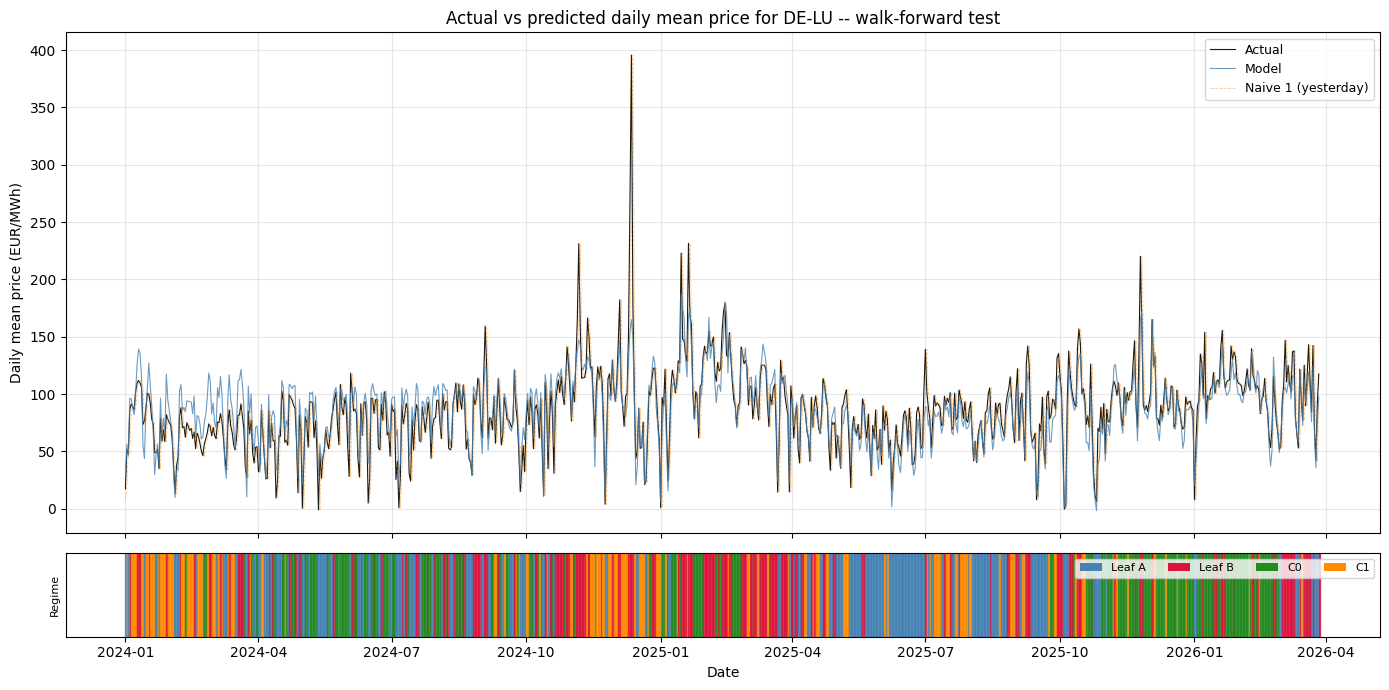

Saved: results/timeseries_actual_vs_predicted_DE-LU.png


In [33]:
plot_timeseries_actual_vs_predicted(df_preds, ZONES[country])

### Average 24-Hour Profile per Regime

Comparing the mean actual curve against the mean predicted curve within each regime reveals whether the expert models have learned the correct intraday shape. A systematic offset across all hours points to a level bias; a shape mismatch at specific hours points to a structural deficiency in the features available for those periods.

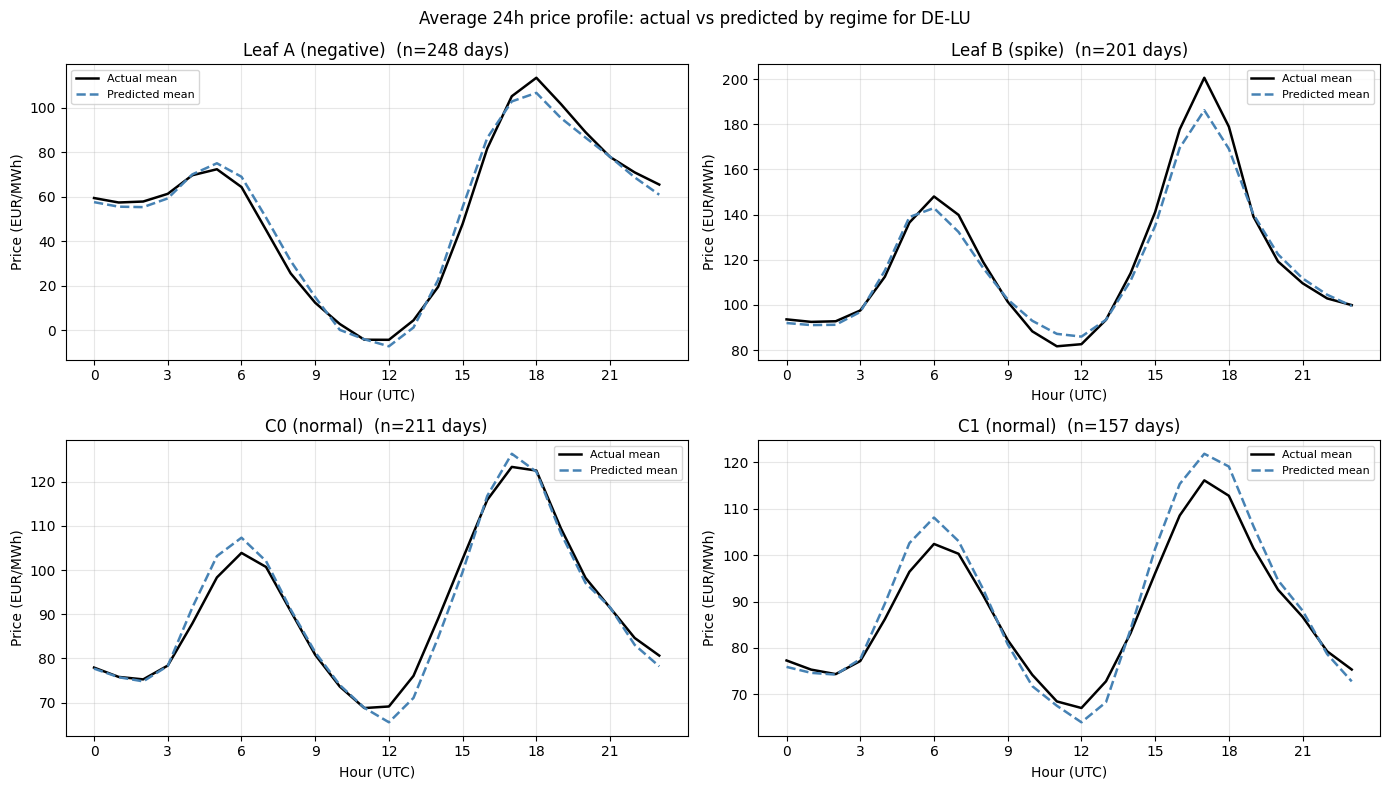

Saved: results/regime_profiles_actual_vs_predicted_DE-LU.png


In [34]:
plot_regime_profiles(df_preds, ZONES[country])

### Error Distribution and Rolling WAPE

The error histogram shows whether prediction mistakes are symmetric around zero (no bias) or skewed (systematic over- or under-prediction). The rolling 30-day WAPE reveals whether accuracy is stable over time or degrades in specific periods, which can indicate a regime shift the model has not adapted to.

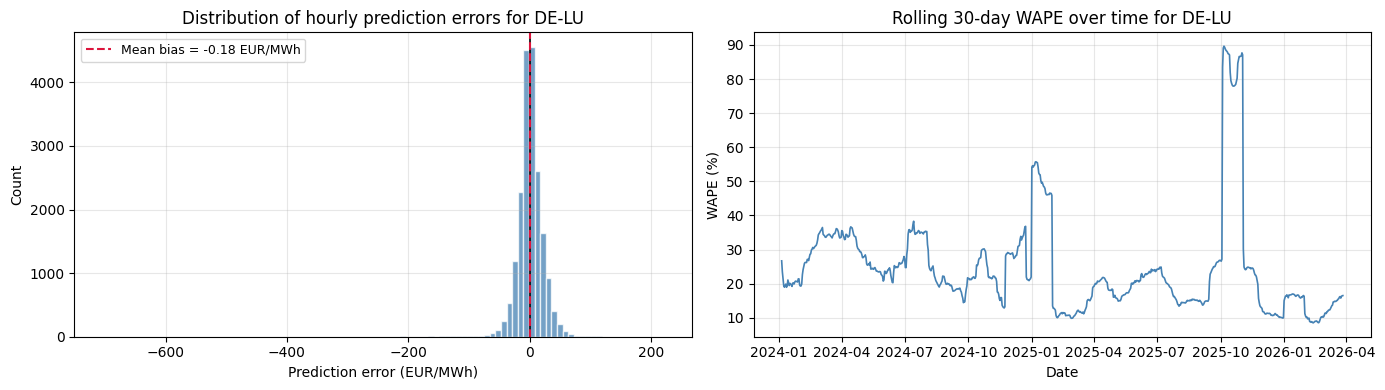

Saved: results/error_distribution_DE-LU.png
Mean error (bias):      -0.18 EUR/MWh
Error std:              25.96 EUR/MWh
Median absolute error:  10.36 EUR/MWh
90th pct absolute error:32.26 EUR/MWh


In [35]:
plot_error_distribution(df_preds, ZONES[country])

### Classifier Regime Probabilities Over Time

The stacked area chart shows how the classifier allocates probability mass across the four regimes day by day. Persistent blue (Leaf A) bands indicate periods of sustained negative prices, red (Leaf B) bands indicate spike clustering. Wide green or orange areas reflect the dominant normal-day regimes. Sudden shifts in the colour mix can reveal structural changes in DK1 market conditions that fall outside the training distribution.

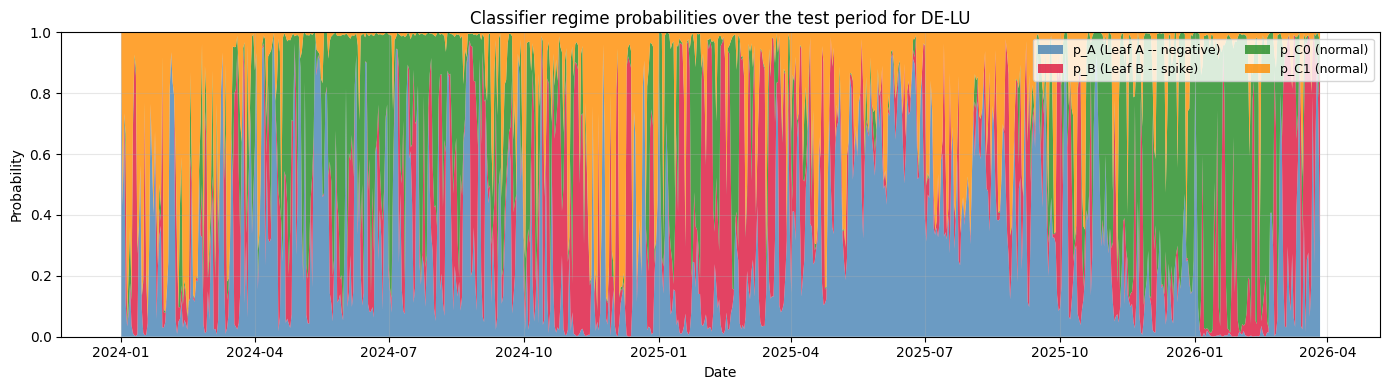

Saved: results/regime_probabilities_DE-LU.png


In [36]:
plot_regime_probabilities(df_preds, ZONES[country])

### Best and Worst Predicted Days

Inspecting the individual days with the highest and lowest daily WAPE and MAE shows whether failures concentrate in specific market conditions or are scattered randomly. Clustered failures suggest a systematic gap in the feature set.

In [37]:
worst_best_days_wape(df_preds, ZONES[country])

=== 10 worst predicted days for DE-LU (by WAPE) ===
      date       regime_name    MAPE%   WAPE%  actual_mean_eur  pred_mean_eur
2025-10-04 Leaf A (negative)  5725.09 1718.30            -0.41           1.49
2025-01-01 Leaf A (negative) 21971.54  976.51             0.97           5.54
2024-11-24 Leaf A (negative) 27760.07  457.98             3.87           6.89
2025-10-05 Leaf A (negative)   615.86  177.04             3.11           1.54
2025-09-15 Leaf A (negative) 12714.91  169.60             7.83          12.89
2026-01-01 Leaf A (negative) 47258.66  164.02             7.73          20.41
2024-07-06 Leaf A (negative) 13118.85  152.23             0.69          26.99
2025-10-26 Leaf A (negative)  9895.21  150.63             6.41          -1.66
2024-07-04 Leaf A (negative) 11399.88  129.12            25.41          62.54
2024-10-13 Leaf A (negative)  6759.46  112.36            11.12          10.74


=== 10 best predicted days for DE-LU (by WAPE) ===
      date    regime_name  MAPE%  WAP

In [38]:
worst_best_days_mae(df_preds, ZONES[country])

=== 10 worst predicted days for DE-LU (by MAE) ===
      date    regime_name    MAE  MAPE%  WAPE%  actual_mean_eur  pred_mean_eur
2024-12-12 Leaf B (spike) 234.66  41.95  59.31           395.66         164.90
2024-12-11 Leaf B (spike) 113.69  33.29  42.61           266.81         153.91
2024-11-06 Leaf B (spike)  91.22  20.18  39.45           231.22         147.42
2025-01-20 Leaf B (spike)  66.65  20.32  28.78           231.58         165.79
2025-11-25 Leaf B (spike)  57.47  19.56  26.10           220.18         165.31
2026-01-08    C0 (normal)  54.69  26.23  35.53           153.91         100.11
2025-07-01 Leaf B (spike)  51.50  31.69  37.05           139.01          88.90
2024-02-27 Leaf B (spike)  46.27  61.70  62.57            73.95         118.35
2024-11-05 Leaf B (spike)  45.84  17.88  27.79           164.98         138.14
2024-02-28 Leaf B (spike)  41.75  58.00  58.31            71.60         111.53


=== 10 best predicted days for DE-LU (by MAE) ===
      date    regime_name  M

### Random Day Visualization

C:\Users\aleks\AppData\Local\Temp\ipykernel_13052\1137132157.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


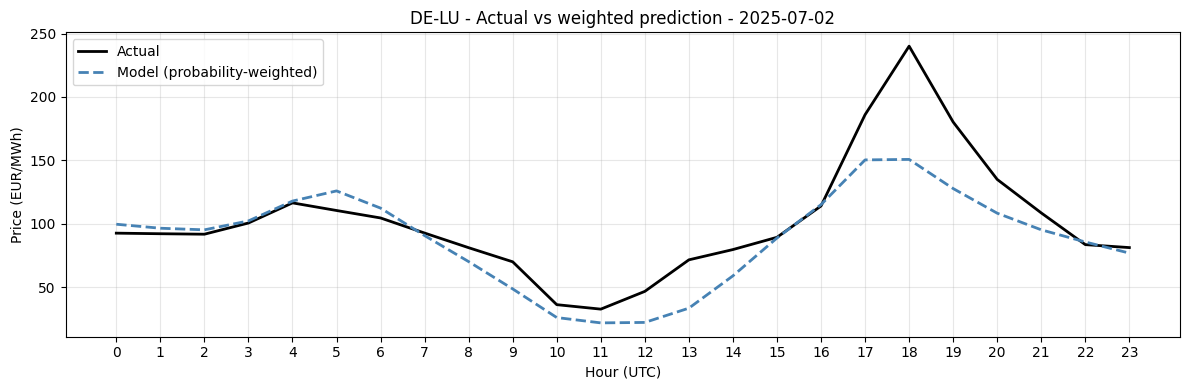

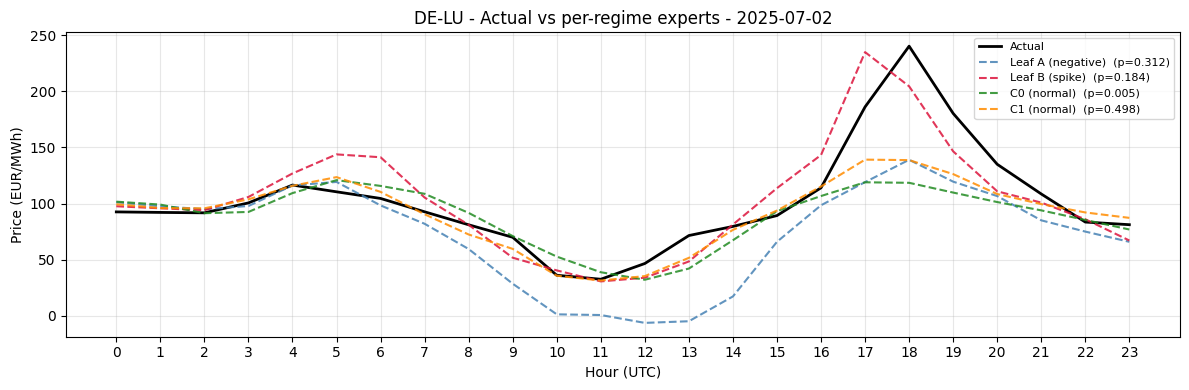

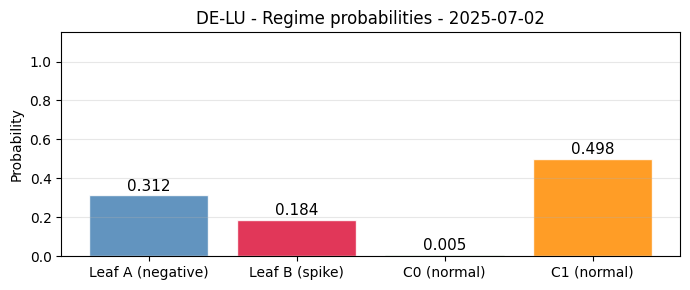

In [39]:
# Random test day
date = df_preds["date"].sample().iloc[0]

figs = plot_single_day_diagnostics(
    date, df_preds, all_fold_models, df_hourly, df_daily, ZONES[country], model_cfg
)
for f in figs:
    f.show()   